# Example 4: Regression on a 3D Surface using SONFIS

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import torch
import torch.nn as nn
import torch.utils.data as data

import numpy as np
import random

import neuro_fuzzy_toolbox as nft

In [21]:
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [22]:
def plot_surface(X: torch.Tensor, Y: torch.Tensor, fig_size=(8, 6)):
    """
    Plots a 3D surface from two input features (x0, x1) in X and heights in Y.

    Args:
        X (torch.Tensor): Input tensor of shape (n, 2) with two independent variables.
        Y (torch.Tensor): Target tensor of shape (n,) with the dependent variable.
        fig_size (tuple): Figure size as (width, height) in inches.
    """
    X_np = X.detach().cpu().numpy()
    Y_np = Y.detach().cpu().numpy()
    x0 = X_np[:, 0]
    x1 = X_np[:, 1]

    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(111, projection="3d")
    
    try:
        xi = np.unique(x0)
        yi = np.unique(x1)
        XI, YI = np.meshgrid(xi, yi)
        Z = Y_np.reshape(len(yi), len(xi))
        ax.plot_surface(XI, YI, Z, cmap='viridis')
    except Exception:
        ax.plot_trisurf(x0, x1, Y_np, linewidth=0.2, antialiased=True, cmap='viridis')
    
    ax.scatter(x0, x1, Y_np, c=Y_np, cmap="viridis", s=1)
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    ax.set_zlabel("y")
    plt.tight_layout()
    plt.show()

## Data

In [23]:
# Target function (peaks-like 3D surface)
def z(x, y):
    return (
        3 * (1 - x)**2 * np.exp(-(x**2) - (y + 1)**2)
        - 10 * (x / 5 - x**3 - y**5) * np.exp(-(x**2) - y**2)
        - (1 / 3) * np.exp(-(x + 1)**2 - y**2)
    )

# Training data with additive Gaussian noise
x0 = np.random.uniform(-3, 3, 1000)
x1 = np.random.uniform(-3, 3, 1000)
noise = np.random.normal(0, 0.5, 1000)
y_noisy = z(x0, x1) + noise

# Test data (noise-free)
x0_test = np.random.uniform(-3, 3, 1000)
x1_test = np.random.uniform(-3, 3, 1000)
y_clean = z(x0_test, x1_test)

X_train_np = np.vstack((x0, x1)).T
X_test_np  = np.vstack((x0_test, x1_test)).T

In [24]:
x_train_np, x_val_np, y_train_np, y_val_np = train_test_split(
    X_train_np, y_noisy, test_size=0.2, random_state=SEED
)

In [25]:
dtype = torch.float64

scaler = MinMaxScaler(feature_range=(0, 1))

x_train = torch.tensor(scaler.fit_transform(x_train_np), dtype=dtype)
x_val   = torch.tensor(scaler.transform(x_val_np),       dtype=dtype)
x_test  = torch.tensor(scaler.transform(X_test_np),      dtype=dtype)

y_train = torch.tensor(y_train_np, dtype=dtype)
y_val   = torch.tensor(y_val_np,   dtype=dtype)
y_test  = torch.tensor(y_clean,    dtype=dtype)

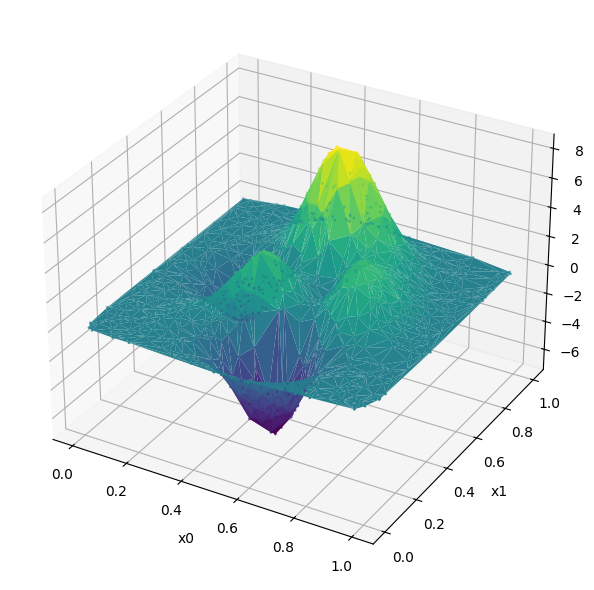

In [26]:
# Visualize the test surface
plot_surface(x_test, y_test)

## DataLoaders

In [27]:
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = data.DataLoader(
    data.TensorDataset(x_train, y_train),
    batch_size=64, shuffle=True, generator=generator
)

val_loader = data.DataLoader(
    data.TensorDataset(x_val, y_val),
    batch_size=64, shuffle=False
)

## Model

In [28]:
# Define model
model = nft.rule_reduced_ANFIS(
    input_size=2,
    num_mfs=3,
    outputs=1,
    membership_function=nft.GeneralizedBell_MF(),
    output_type='default',
    dtype=dtype
)

In [29]:
model.init_premises(x_train)
model.init_consequents(x_train, y_train, driver="gelsd", ridge_lambda=1.0)

## Learning Algorithm

In [30]:
# Define the parameter training algorithm to be used inside SONFIS
anfis_trainer = nft.Basic_optimizer_training_algorithm(
    epochs=500,
    loss_function=nn.MSELoss(),
    optimizer=torch.optim.AdamW,
    optimizer_params={'lr': 5e-3, 'weight_decay': 1e-2},
    early_stopping=nft.EarlyStopping(patience=30, delta=1e-3)
)

## SONFIS

In [31]:
# Define SONFIS
sonfis = nft.SONFIS(
    Ngrow=100,
    dGrow=0.8,
    Nsplit=140,
    eSplit=0.15,
    Nvanish=10,
    lVanish=3,
    max_iterations=100,
    ANFIStrainer=anfis_trainer,
    early_stopping=nft.EarlyStopping(patience=15),
    lse_for_new_consequents=True,
    lse_for_new_consequents_lambda=1e-1,
    last_training_iteration=True
)

In [32]:
# Train model
sonfis(model, train_loader, val_loader)

ITERATION:   0/100

STARTING STATE:
   premises                                                   output 1 consequents                     
         x0                            x1                                       x0         x1          
          a         b         c         a         b         c                   c0         c1        c2
0  0.223534  2.539785  0.119831  0.308182  7.149249  0.346588             0.752955  -0.953248 -0.038301
1  0.082473  2.357693  0.515031  0.331031  7.980209  0.500444             0.841475  15.006280 -6.595521
2  0.240233  1.063071  1.168134  0.189384  2.650574  1.017342             0.005708   0.464412 -0.263461

	loss: 2.535220 - validation loss: 2.349976
	 --> ANFIS rules: 3


ITERATION:   1/100
	-> Growing 3 new subnets: [3, 4, 5]

CURRENT STATE:
   premises                                                   output 1 consequents                      
         x0                            x1                                       x0         x1  

## Evaluation

In [33]:
pred = model.predict(x_test)

mse  = mean_squared_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)

print("MSE: ", mse)
print("RMSE:", rmse)
print("MAE: ", mae)
print("R2:  ", r2)
print("MAPE:", mape)

MSE:  0.18704400823769493
RMSE: 0.43248584744208096
MAE:  0.2957790657497346
R2:   0.9462171057884828
MAPE: 40.81359011343615


Test surface:


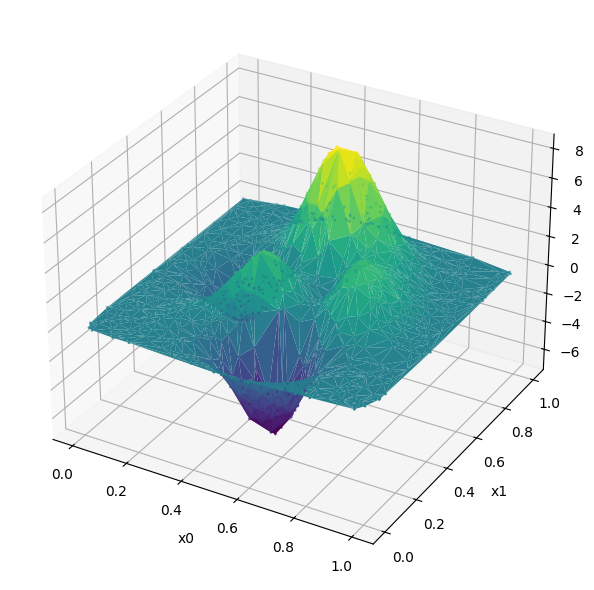

Model predictions:


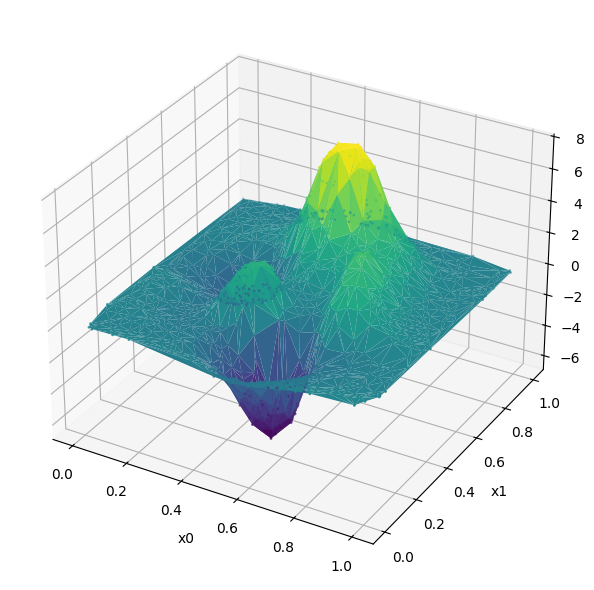

In [34]:
print("Test surface:")
plot_surface(x_test, y_test)

print("Model predictions:")
plot_surface(x_test, pred)

In [35]:
print(model.rules)

12
